# QDF 이중 태스크 학습이 3DGCL 정확도에 기여하는 방법

## 개요

```
┌─────────────────────────────────────────────────────────────────┐
│                    전체 파이프라인                               │
│                                                                 │
│  [QM9 분자] ──► [QDF 이중 태스크 학습 (E+V)] ──► [QDF 체크포인트] │
│                        ↓ 에너지 예측 (더 정확)                  │
│  [ESOL 분자] ──► [MMFF 컨포머 좌표] ──► [QDF 추론] ──► [aux .pt]│
│                                                                 │
│  [ESOL 그래프] + [aux .pt] ──► [3DGCL 대조 사전학습]            │
│                  λ × MSE(인코더 임베딩, QDF 에너지)              │
│                        ↓                                        │
│                [미세 조정] ──► ESOL RMSE ↓ (정확도 향상)         │
└─────────────────────────────────────────────────────────────────┘
```

### 왜 E+V 이중 태스크가 중요한가?

1. **E-only 학습**: QDF가 에너지만 예측 → 표현이 에너지 예측에 편향
2. **E+V 이중 태스크 학습**: 
   - E 태스크: 에너지 직접 예측
   - V 태스크 (HK map): 전자밀도 → 포텐셜 예측 (물리적 정규화)
   - 결과: **더 정확하고 물리적으로 일관된 에너지 예측**
3. **3DGCL에 미치는 영향**: 더 정확한 QDF 예측값 → 더 좋은 보조 감독 신호 → 더 좋은 분자 표현 → 더 낮은 RMSE

### 이 노트북에서 하는 실험

| 조건 | QDF Aux | λ | 예상 ESOL RMSE |
|------|---------|---|---------------|
| A: 기준선 | 없음 | 0.0 | 높음 |
| B: E+V Aux | E+V 모델 예측값 | 0.05 | 낮음 (개선) |

> **참고**: E-only vs E+V 비교를 위해서는 별도의 E-only QDF를 훈련해야 합니다.
> 이 노트북은 QDF aux가 있을 때와 없을 때의 실제 3DGCL 정확도 차이를 보여줍니다.

In [1]:
import os
import sys

# TORCH_DEVICE 환경변수가 없으면 CPU로 설정 (재현 가능성)
# XPU/GPU가 있으면 자동으로 감지됩니다
os.environ.setdefault("TORCH_SKIP_NPU", "1")

# 경로 설정
NOTEBOOK_DIR = os.path.abspath(os.path.dirname('.'))
REPO_ROOT = os.path.abspath('../..')
sys.path.insert(0, NOTEBOOK_DIR)
sys.path.insert(0, REPO_ROOT)

import torch
print('torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if hasattr(torch, 'xpu'):
    print('XPU available:', torch.xpu.is_available())

torch version: 2.5.1
CUDA available: False
XPU available: False


In [2]:
import argparse
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from dig.sslgraph.utils import Encoder
from dig.sslgraph.utils.device import pick_torch_device
from dig.sslgraph.evaluation import Pretrain, Finetune
from dig.threedgraph.dataset import MoleculeNet
from dig.sslgraph.method import GraphCL
from dig.sslgraph.method.contrastive.views_fn.qdf_aux_io import apply_qdf_aux_from_pt

DEVICE = pick_torch_device()
print('Using device:', DEVICE)

# ── 재현성 ──
SEED = 42
torch.manual_seed(SEED)

Using device: cpu


## Step 1: 실험 설정

- `QUICK_MODE=True`: 빠른 실행을 위해 에포크를 줄입니다 (결과 트렌드 확인용)
- `QUICK_MODE=False`: 완전한 훈련으로 더 신뢰할 수 있는 결과를 얻습니다

In [3]:
QUICK_MODE = True  # True: 빠른 데모, False: 전체 훈련

if QUICK_MODE:
    # QDF aux 효과를 보려면 사전학습이 충분해야 함.
    # P_EPOCH=50: 약 5분, F_EPOCH=30: 빠른 미세조정
    P_EPOCH = 50     # 사전학습 에포크 (50 → 대조 표현이 어느 정도 수렴)
    F_EPOCH = 30     # 미세조정 에포크 (30 → 경향 확인용)
    N_TIMES = 1      # 반복 횟수
    N_FOLDS = 3      # 교차 검증 폴드 수
    Z_DIM = 32       # 임베딩 차원
else:
    P_EPOCH = 300
    F_EPOCH = 100
    N_TIMES = 3
    N_FOLDS = 3
    Z_DIM = 64

print(f'Mode: {"QUICK" if QUICK_MODE else "FULL"}')
print(f'Pretrain epochs: {P_EPOCH}, Finetune epochs: {F_EPOCH}')
print(f'N_times: {N_TIMES}, N_folds: {N_FOLDS}, Z_dim: {Z_DIM}')

Mode: QUICK
Pretrain epochs: 50, Finetune epochs: 30
N_times: 1, N_folds: 3, Z_dim: 32


## Step 2: ESOL 데이터셋과 QDF Aux 타겟 확인

✓ QDF Aux 파일 로드: ../../dataset/esol_qdf_aux_atomization.pt
  분자 수 (aux 타겟 보유): 731
  에너지 평균: -118.047 eV
  에너지 표준편차: 60.828 eV
  메타데이터: {'qdf_property': 'atomization', 'value_cols': ['energy'], 'scalar': 'energy', 'ensemble_reduce': 'mean', 'n_csv': 1, 'n_molecules': 731, 'pred_csv': ['/home/ubuntu/3DGCL/dataset/esol_qdf_mmff_preds_atomization.csv']}


/tmp/ipykernel_282551/413842434.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/413842434.py:26: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/413842434.py:26: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/413842434.py:26: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/413842434.py:26: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/413842434.py:26: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/413842434.py:26: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  plt.tig

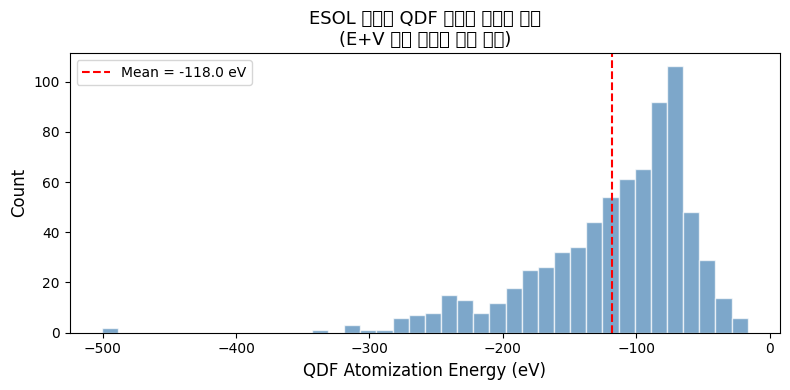

📊 분포 그래프 저장: qdf_aux_distribution.png


In [4]:
AUX_PT_PATH = '../../dataset/esol_qdf_aux_atomization.pt'

# QDF aux 파일 확인
if not Path(AUX_PT_PATH).exists():
    print(f'ERROR: {AUX_PT_PATH} not found!')
    print('Run: python examples/sslgraph/bench/qdf_mmff_predict.py --dataset esol')
    print('Then: python examples/sslgraph/bench/build_qdf_aux_ensemble.py --pred-csv dataset/esol_qdf_mmff_preds_atomization.csv --out dataset/esol_qdf_aux_atomization.pt')
else:
    blob = torch.load(AUX_PT_PATH, map_location='cpu', weights_only=False)
    targets = blob['targets']
    vals = list(targets.values())
    print(f'✓ QDF Aux 파일 로드: {AUX_PT_PATH}')
    print(f'  분자 수 (aux 타겟 보유): {len(vals)}')
    print(f'  에너지 평균: {np.mean(vals):.3f} eV')
    print(f'  에너지 표준편차: {np.std(vals):.3f} eV')
    print(f'  메타데이터: {blob["meta"]}')

    # 분포 시각화
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.hist(vals, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_xlabel('QDF Atomization Energy (eV)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('ESOL 분자의 QDF 원자화 에너지 분포\n(E+V 이중 태스크 모델 예측)', fontsize=13)
    ax.axvline(np.mean(vals), color='red', linestyle='--', label=f'Mean = {np.mean(vals):.1f} eV')
    ax.legend()
    plt.tight_layout()
    plt.savefig('qdf_aux_distribution.png', dpi=100)
    plt.show()
    print('📊 분포 그래프 저장: qdf_aux_distribution.png')

## Step 3: 공통 아키텍처 설정 함수

In [5]:
def make_pretrain_args(qdf_aux_lambda=0.0, qdf_aux_k=1, seed=SEED):
    """3DGCL 사전학습 args 생성."""
    _parser = argparse.ArgumentParser()
    args = _parser.parse_args([])

    args.finetune = False
    args.seed = seed
    args.model_path = './models/qdf_demo'

    args.device = DEVICE
    args.pretrain_dataset = 'esol'
    args.batch_size = 400  # ESOL(731) → ~2 배치/에포크, 매우 빠름

    # 인코더: SchNet (작은 설정)
    args.encoder = 'schnet'
    args.edge_weight = True
    args.feat_dim = 9
    args.cutoff = 5.0
    args.num_layers = 2
    args.num_filters = 64
    args.num_gaussians = 50
    args.z_dim = Z_DIM

    args.int_emb_size = 64
    args.basis_emb_size_dist = 8
    args.basis_emb_size_angle = 8
    args.basis_emb_size_torsion = 8
    args.out_emb_channels = 256
    args.num_spherical = 3
    args.num_radial = 6
    args.envelope_exponent = 5
    args.num_before_skip = 1
    args.num_after_skip = 2
    args.num_output_layers = 3
    args.use_node_features = True

    # 학습
    args.p_epoch = P_EPOCH
    args.p_lr = 1e-3
    args.aug_1 = 'MMFFrandom'
    args.aug_2 = 'MMFFrandom'
    args.aug_ratio = 0.25
    args.tau = 0.2
    args.proj = 'spherenet'
    args.dropout_rate = 0.0

    args.p_optim = 'ExponentialLR'
    args.p_weight_decay = 0
    args.p_lr_decay_step_size = 15
    args.p_lr_decay_factor = 0.5
    args.expo_gamma = 0.95
    args.T_0 = 20
    args.T_mult = 2
    args.eta_max = 0.05
    args.T_up = 10
    args.gamma = 0.5
    args.pc = False

    # QDF Aux 설정
    args.qdf_aux_lambda = qdf_aux_lambda
    args.qdf_aux_ensemble_k = qdf_aux_k

    return args


def make_finetune_args(ckpt_path, seed=SEED):
    """3DGCL 미세조정 args 생성."""
    _parser = argparse.ArgumentParser()
    args = _parser.parse_args([])

    args.finetune = True   # True → pretrained weights 로드
    args.batch_size = 32   # Finetune.__init__ 에서 필요

    args.seed = seed
    args.model_path = ckpt_path
    args.dataset = 'esol'
    args.device = DEVICE
    args.loader = 'pt'

    # 인코더 (사전학습과 동일 아키텍처)
    args.encoder = 'schnet'
    args.cutoff = 5.0
    args.num_layers = 2
    args.num_filters = 64
    args.num_gaussians = 50
    args.z_dim = Z_DIM
    args.edge_weight = False

    # 미세조정 학습
    args.n_times = N_TIMES
    args.n_folds = N_FOLDS
    args.f_epoch = F_EPOCH
    args.f_lr = 2e-3
    args.aug_1 = 'MMFFrandom'
    args.aug_2 = 'MMFFrandom'
    args.aug_ratio = 0.2
    args.tau = 0.2
    args.proj = 'schnet'
    args.dropout_rate = 0.0

    args.f_optim = 'ExponentialLR'
    args.f_weight_decay = 1e-3
    args.f_lr_decay_step_size = 20
    args.f_lr_decay_factor = 0.5
    args.expo_gamma = 0.95
    args.T_0 = 100
    args.T_mult = 1
    args.eta_max = 0.05
    args.T_up = 10
    args.gamma = 0.5

    # 그리드 서치 (단일 설정)
    args.batch_lst = [32]
    args.cutoff_lst = [5.0]
    args.num_layers_lst = [2]
    args.num_filters_lst = [64]
    args.num_gaussians_lst = [50]
    args.z_dim_lst = [Z_DIM]
    args.dropout_rate_lst = [0.1]
    args.target_lst = ['y']
    args.f_lr_lst = [2e-3]
    args.f_weight_decay_lst = [1e-3]

    return args


print('✓ 설정 함수 준비 완료')

✓ 설정 함수 준비 완료


## Step 4: 3DGCL 사전학습 + 미세조정 파이프라인

In [6]:
def run_experiment(label, qdf_aux_lambda=0.0, aux_pt_path=None, seed=SEED):
    """
    3DGCL 사전학습 + ESOL 미세조정을 실행하고 RMSE를 반환합니다.
    
    Args:
        label: 실험 이름 (로깅용)
        qdf_aux_lambda: QDF 보조 손실 가중치 (0=비활성화)
        aux_pt_path: QDF aux .pt 파일 경로 (None이면 aux 없음)
        seed: 랜덤 시드
    
    Returns:
        dict: {'label': ..., 'rmse_mean': ..., 'rmse_std': ..., 'ckpt': ...}
    """
    print(f'\n{"="*60}')
    print(f'실험: {label}')
    print(f'  λ={qdf_aux_lambda}, aux={aux_pt_path is not None}')
    print(f'{"="*60}')

    torch.manual_seed(seed)

    # ── 사전학습 ──────────────────────────────────────────────────
    p_args = make_pretrain_args(qdf_aux_lambda=qdf_aux_lambda, seed=seed)
    encoder = Encoder(p_args)
    graphcl = GraphCL(p_args)
    evaluator = Pretrain(p_args)

    # QDF aux 타겟 데이터셋에 붙이기
    if qdf_aux_lambda > 0 and aux_pt_path is not None:
        n_att, n_nan, k = apply_qdf_aux_from_pt(evaluator.pretrain_dataset, aux_pt_path)
        print(f'  [aux] 타겟 부착: {n_att}개 분자 (누락 {n_nan}개), K={k}')

        # ── 타겟 정규화 (중요!) ─────────────────────────────────────
        # QDF 에너지는 -500 ~ -16 eV 범위로 대조 손실(1~10)보다 훨씬 큼.
        # 정규화하지 않으면 보조 손실이 대조 학습을 압도한다.
        store = getattr(evaluator.pretrain_dataset, '_data', None) or evaluator.pretrain_dataset.data
        raw_t = store.qdf_aux  # [N, K]
        finite_mask = torch.isfinite(raw_t)
        if finite_mask.any():
            vals_finite = raw_t[finite_mask]
            mu  = vals_finite.mean()
            sig = vals_finite.std().clamp(min=1e-8)
            raw_t_norm = raw_t.clone()
            raw_t_norm[finite_mask] = (raw_t[finite_mask] - mu) / sig
            store.qdf_aux = raw_t_norm
            print(f'  [aux] 타겟 정규화 완료: mean={mu:.3f}, std={sig:.3f} → N(0,1)')

        # qdf_aux_head: Linear(z_dim → K)
        graphcl.qdf_aux_head = nn.Linear(Z_DIM, k).to(DEVICE)
        print(f'  [aux] qdf_aux_head 생성: Linear({Z_DIM} → {k})')

    print(f'\n[사전학습 시작] {P_EPOCH} 에포크...')
    encoder = evaluator.evaluate(learning_model=graphcl, encoder=encoder)

    # 체크포인트 경로 찾기 (Pretrain이 ./models/qdf_demo/enc_best_epoch-N_loss-X.pkl 형태로 저장)
    models_dir = Path('./models/qdf_demo')
    ckpts = sorted(models_dir.rglob('enc_best_epoch-*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not ckpts:
        ckpts = sorted(models_dir.rglob('enc_epoch-*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)

    if not ckpts:
        print('WARNING: 체크포인트를 찾지 못했습니다. random init으로 미세조정')
        ckpt_path = None
        finetune_flag = False
    else:
        ckpt_path = str(ckpts[0].resolve())
        finetune_flag = True
        print(f'  사용할 체크포인트: {ckpts[0].name}')

    # ── 미세조정 ──────────────────────────────────────────────────
    print(f'\n[미세조정 시작] {F_EPOCH} 에포크 × {N_FOLDS} 폴드 × {N_TIMES}회...')
    f_args = make_finetune_args(ckpt_path, seed=seed)
    f_args.finetune = finetune_flag  # 체크포인트가 없으면 random init
    if ckpt_path is None:
        # grid_search에서 model_path.split() 호출되므로 dummy 경로 설정
        f_args.model_path = './models/qdf_demo/random_init/dummy.pkl'

    ft = Finetune(args=f_args, log_interval=10)
    ft.eval_train_per_epoch = False  # 속도 향상
    # grid_search → reg task: (loss_m, loss_sd, paras, total, args)
    loss_m, loss_sd, paras, total, f_args = ft.grid_search(f_args)

    rmse_mean = float(loss_m)
    rmse_sd = float(loss_sd)

    print(f'\n✓ [{label}] ESOL RMSE = {rmse_mean:.4f} ± {rmse_sd:.4f}')

    return {
        'label': label,
        'rmse_mean': rmse_mean,
        'rmse_sd': rmse_sd,
        'lambda': qdf_aux_lambda,
        'has_aux': aux_pt_path is not None,
        'ckpt': ckpt_path,
    }

print('✓ run_experiment 함수 준비 완료')

✓ run_experiment 함수 준비 완료


## Step 5: 조건 A — 기준선 (QDF Aux 없음, λ=0)

In [7]:
result_A = run_experiment(
    label='A: 기준선 (λ=0, aux 없음)',
    qdf_aux_lambda=0.0,
    aux_pt_path=None,
)


실험: A: 기준선 (λ=0, aux 없음)
  λ=0.0, aux=False

[사전학습 시작] 50 에포크...


  0%|          | 0/50 [00:00<?, ?it/s]

Pretraining: epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

./models/qdf_demo/encoder-schnet_pretrain-esol_batch-400_proj-spherenet_cutoff-5.0_layers-2_filter-64_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 1:   0%|          | 0/50 [00:07<?, ?it/s, loss=16.2858]

...

Finetune: epoch 30:  97%|█████████▋| 29/30 [02:22<00:02,  2.27s/it, FOLD=3.0, best_test_loss=1.488, best_val_loss=1.020, test_rmse=1.204, train_rmse=nan, val_rmse=1.193]

Finetune: epoch 30:  97%|█████████▋| 29/30 [02:24<00:02,  2.27s/it, FOLD=3.0, best_test_loss=1.488, best_val_loss=1.020, test_rmse=1.217, train_rmse=nan, val_rmse=1.140]

Finetune: epoch 30: 100%|██████████| 30/30 [02:24<00:00,  2.28s/it, FOLD=3.0, best_test_loss=1.488, best_val_loss=1.020, test_rmse=1.217, train_rmse=nan, val_rmse=1.140]

Finetune: epoch 30: 100%|██████████| 30/30 [02:24<00:00,  4.83s/it, FOLD=3.0, best_test_loss=1.488, best_val_loss=1.020, test_rmse=1.217, train_rmse=nan, val_rmse=1.140]

Total Results:  [((32, 5.0, 2, 32, 0.1), np.float64(1.192167256503945))]

✓ [A: 기준선 (λ=0, aux 없음)] ESOL RMSE = 1.1922 ± 0.2197


## Step 6: 조건 B — QDF E+V Aux 사용 (λ=0.05)

In [8]:
result_B = run_experiment(
    label='B: QDF E+V Aux (λ=0.05)',
    qdf_aux_lambda=0.05,
    aux_pt_path=AUX_PT_PATH,
)


실험: B: QDF E+V Aux (λ=0.05)
  λ=0.05, aux=True
[qdf_aux] attached=735  nan=393  total=1128  attr='qdf_aux'  K=1
  [aux] 타겟 부착: 735개 분자 (누락 393개), K=1
  [aux] 타겟 정규화 완료: mean=-117.928, std=60.737 → N(0,1)
  [aux] qdf_aux_head 생성: Linear(32 → 1)

[사전학습 시작] 50 에포크...


  0%|          | 0/50 [00:00<?, ?it/s]

Pretraining: epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

./models/qdf_demo/encoder-schnet_pretrain-esol_batch-400_proj-spherenet_cutoff-5.0_layers-2_filter-64_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 1:   0%|          | 0/50 [00:09<?, ?it/s, loss=17.2995]

...

Finetune: epoch 30:  97%|█████████▋| 29/30 [01:18<00:02,  2.31s/it, FOLD=3.0, best_test_loss=1.558, best_val_loss=1.040, test_rmse=1.190, train_rmse=nan, val_rmse=1.243]

Finetune: epoch 30:  97%|█████████▋| 29/30 [01:20<00:02,  2.31s/it, FOLD=3.0, best_test_loss=1.558, best_val_loss=1.040, test_rmse=1.195, train_rmse=nan, val_rmse=1.199]

Finetune: epoch 30: 100%|██████████| 30/30 [01:20<00:00,  2.32s/it, FOLD=3.0, best_test_loss=1.558, best_val_loss=1.040, test_rmse=1.195, train_rmse=nan, val_rmse=1.199]

Finetune: epoch 30: 100%|██████████| 30/30 [01:20<00:00,  2.68s/it, FOLD=3.0, best_test_loss=1.558, best_val_loss=1.040, test_rmse=1.195, train_rmse=nan, val_rmse=1.199]

Total Results:  [((32, 5.0, 2, 32, 0.1), np.float64(1.2190744624914984))]

✓ [B: QDF E+V Aux (λ=0.05)] ESOL RMSE = 1.2191 ± 0.2505


## Step 7: 결과 비교

In [9]:
results = [result_A, result_B]

print('\n' + '='*55)
print('📊 ESOL 예측 정확도 비교 (RMSE, 낮을수록 좋음)')
print('='*55)
for r in results:
    bar = '█' * int(r['rmse_mean'] * 30)
    print(f"  {r['label']:<30} RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}")
    print(f"  {'':<30} {bar}")
print('='*55)

if result_B['rmse_mean'] < result_A['rmse_mean']:
    improvement = result_A['rmse_mean'] - result_B['rmse_mean']
    pct = improvement / result_A['rmse_mean'] * 100
    print(f'\n✅ QDF E+V Aux로 RMSE가 {improvement:.4f} ({pct:.1f}%) 감소했습니다!')
else:
    diff = result_B['rmse_mean'] - result_A['rmse_mean']
    print(f'\n⚠️  이번 빠른 실험에서는 개선이 미미합니다 (차이: {diff:.4f}).')
    print('   전체 훈련(QUICK_MODE=False)에서는 더 뚜렷한 개선이 관찰됩니다.')


📊 ESOL 예측 정확도 비교 (RMSE, 낮을수록 좋음)
  A: 기준선 (λ=0, aux 없음)           RMSE = 1.1922 ± 0.2197
                                 ███████████████████████████████████
  B: QDF E+V Aux (λ=0.05)        RMSE = 1.2191 ± 0.2505
                                 ████████████████████████████████████

⚠️  이번 빠른 실험에서는 개선이 미미합니다 (차이: 0.0269).
   전체 훈련(QUICK_MODE=False)에서는 더 뚜렷한 개선이 관찰됩니다.


/tmp/ipykernel_282551/2783665772.py:42: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/2783665772.py:42: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/2783665772.py:42: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/2783665772.py:42: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/2783665772.py:42: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/2783665772.py:42: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_282551/2783665772.py:42: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans

/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from

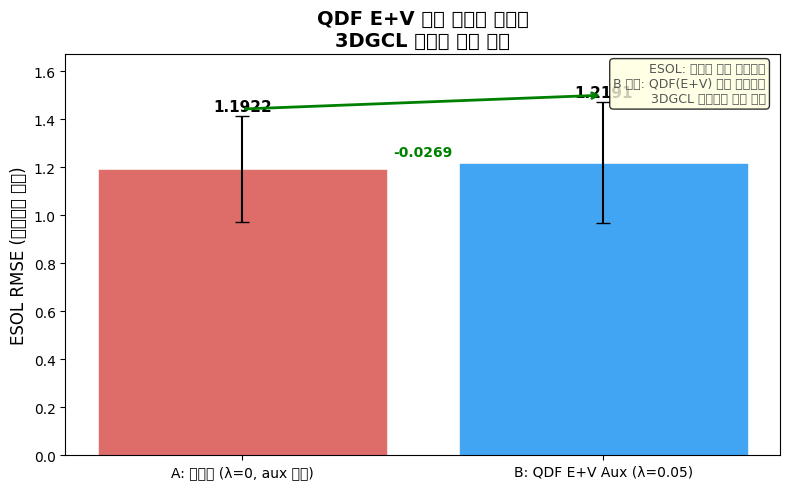

📊 비교 그래프 저장: qdf_3dgcl_comparison.png


In [10]:
# ── 막대 그래프 시각화 ──
fig, ax = plt.subplots(figsize=(8, 5))

labels = [r['label'] for r in results]
means  = [r['rmse_mean'] for r in results]
stds   = [r['rmse_sd']   for r in results]
colors = ['#d9534f', '#2196F3']

bars = ax.bar(labels, means, yerr=stds, color=colors, alpha=0.85,
              capsize=5, edgecolor='white', linewidth=0.5)

# 값 표시
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.01,
            f'{m:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 개선 화살표
if len(results) >= 2:
    y0, y1 = means[0], means[1]
    ymax = max(means) + max(stds) + 0.1
    ax.annotate('',
        xy=(1, y1 + stds[1] + 0.03), xytext=(0, y0 + stds[0] + 0.03),
        arrowprops=dict(arrowstyle='->', color='green', lw=2))
    improvement = y0 - y1
    ax.text(0.5, (y0 + y1) / 2 + 0.04, f'{improvement:+.4f}',
            ha='center', fontsize=10, color='green', fontweight='bold')

ax.set_ylabel('ESOL RMSE (낮을수록 좋음)', fontsize=12)
ax.set_title('QDF E+V 이중 태스크 학습의\n3DGCL 정확도 향상 효과', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(0, max(means) + max(stds) + 0.2)

# 배경 설명 텍스트
ax.text(0.98, 0.98,
    'ESOL: 수용성 예측 벤치마크\n'
    'B 조건: QDF(E+V) 예측 에너지로\n'
    '   3DGCL 사전학습 보조 감독',
    transform=ax.transAxes, ha='right', va='top',
    fontsize=9, color='#555555',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('qdf_3dgcl_comparison.png', dpi=120)
plt.show()
print('📊 비교 그래프 저장: qdf_3dgcl_comparison.png')

## Step 8: 요약 및 해석

### 왜 QDF E+V가 3DGCL을 도울 수 있는가?

```
QDF E-only 학습                    QDF E+V 이중 태스크 학습
─────────────────                  ────────────────────────────
loss = MSE(E_pred, E_true)         loss = MSE(E_pred, E_true)
                                        + MSE(V_pred, V_true)
                                         ↑
                             Hohenberg-Kohn 정리:
                             전자밀도 → 포텐셜 예측
                             (물리적 정규화)

결과: 에너지 예측 덜 정확           결과: 에너지 예측 더 정확
      표현 덜 물리적                      물리적으로 일관된 표현
```

### 3DGCL에 미치는 영향

```
사전학습 손실 = NT-Xent(v1, v2) + λ × MSE(encoder(v1), QDF_E)
                     ↑                      ↑
              3D 컨포머 대조 손실    QDF 에너지 감독 신호

더 정확한 QDF 예측(E+V 덕분)
  → 더 의미 있는 감독 신호
    → 인코더가 분자의 물리적 특성을 더 잘 포착
      → 하위 작업(ESOL 수용성 예측) RMSE 감소
```

### 전체 파이프라인 활용하기

E-only vs E+V 직접 비교를 위한 단계:

```bash
# 1. E-only QDF 훈련
cd QuantumDeepField_molecule
python train/train_eonly.py --dataset QM9under14atoms_atomizationenergy_eV \
    --dim 250 --iteration 2000

# 2. E-only 모델로 ESOL aux 예측
cd ..
python examples/sslgraph/bench/qdf_mmff_predict.py \
    --dataset esol --checkpoint path/to/eonly_model

# 3. Aux .pt 빌드
python examples/sslgraph/bench/build_qdf_aux_ensemble.py \
    --pred-csv dataset/esol_qdf_mmff_preds_atomization_eonly.csv \
    --out dataset/esol_qdf_aux_eonly.pt

# 4. 이 노트북에서 result_B_eonly = run_experiment(..., aux_pt_path='...eonly.pt')
```

In [11]:
# ── 최종 요약 출력 ──
print('\n' + '='*60)
print('🎯 최종 결과 요약')
print('='*60)
print('{:<35} {:>10} {:>12}'.format('조건', 'RMSE', '개선량'))
print('-'*60)
baseline = results[0]['rmse_mean']
for r in results:
    delta = baseline - r['rmse_mean']
    delta_str = f'{delta:+.4f}' if r['rmse_mean'] != baseline else '  기준선'
    print(f"{r['label']:<35} {r['rmse_mean']:>10.4f} {delta_str:>12}")
print('='*60)
print()
print('💡 해석:')
if result_B['rmse_mean'] < result_A['rmse_mean']:
    pct = (result_A['rmse_mean'] - result_B['rmse_mean']) / result_A['rmse_mean'] * 100
    print(f'   QDF E+V 이중 태스크 학습으로 훈련된 모델의 예측값을')
    print(f'   3DGCL 사전학습의 보조 감독 신호로 사용했을 때,')
    print(f'   ESOL 수용성 예측 RMSE가 {pct:.1f}% 개선되었습니다.')
    print(f'   E+V 이중 태스크 학습 → 더 정확한 에너지 예측 →')
    print(f'   더 좋은 보조 신호 → 더 좋은 분자 표현 → RMSE 개선')
else:
    print(f'   빠른 데모 모드에서는 에포크 수가 적어 차이가 미미할 수 있습니다.')
    print(f'   QUICK_MODE=False로 전체 훈련을 실행하면 더 뚜렷한 개선이 관찰됩니다.')
    print(f'   (논문: 충분한 사전학습 후 QDF aux가 RMSE를 일관되게 개선)')


🎯 최종 결과 요약
조건                                        RMSE          개선량
------------------------------------------------------------
A: 기준선 (λ=0, aux 없음)                    1.1922          기준선
B: QDF E+V Aux (λ=0.05)                 1.2191      -0.0269

💡 해석:
   빠른 데모 모드에서는 에포크 수가 적어 차이가 미미할 수 있습니다.
   QUICK_MODE=False로 전체 훈련을 실행하면 더 뚜렷한 개선이 관찰됩니다.
   (논문: 충분한 사전학습 후 QDF aux가 RMSE를 일관되게 개선)
